In [ ]:
#Stage 2 Geneformer V2


In [ ]:
from pathlib import Path
import pandas as pd
import scanpy as sc

# Keep Scanpy plots compact for notebook viewing
sc.settings.set_figure_params(dpi=100, dpi_save=100)

PROJECT_DIR = Path.cwd()

DATA_FILE = PROJECT_DIR / "data" / "nsclc" / "nsclc_integrated.h5ad"

STAGE1_H5AD = PROJECT_DIR / "input_data" / "01_primary_celltype" / "01_primary_celltype.h5ad"

STAGE2_INPUT_DIR = PROJECT_DIR / "input_data" / "02_disease"
STAGE2_INPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_MODEL_DIR = PROJECT_DIR.parent / "Geneformer-V2-104M"  # change if your model is elsewhere

print(DATA_FILE)
print(STAGE1_H5AD)

In [ ]:
#TBC..
#load stage 1
ad1 = sc.read_h5ad(STAGE1_H5AD, backed="r")

stage1_cell_ids = set(ad1.obs["cell_id"].astype(str))

ad1.file.close()

print("Stage 1 cells:", len(stage1_cell_ids))

In [ ]:
#check original dataset in backend
adata_b = sc.read_h5ad(DATA_FILE, backed="r")

obs = adata_b.obs.copy()

print("Full dataset:", adata_b.shape)
print("Obs:", obs.shape)

In [ ]:
#exclude stage1 cells
obs = obs[~obs.index.astype(str).isin(stage1_cell_ids)].copy()

print("Remaining after excluding Stage 1:", obs.shape)

In [ ]:
#donor-aware sampling again
KEEP_CELL_TYPES = [
    "Macrophage alveolar",
    "Macrophage",
    "Monocyte",
    "T cell CD4",
    "T cell CD8",
    "NK cell",
    "B cell",
    "Endothelial cell",
    "cDC2",
]
# avoid including non-small cell lung carcinoma as non-specific subset of the atlas
KEEP_DISEASES = [
    "normal",
    "chronic obstructive pulmonary disease",
    "lung adenocarcinoma",
    "squamous cell lung carcinoma",
    
]

mask = (
    obs["cell_type_major"].isin(KEEP_CELL_TYPES)
    & obs["disease"].isin(KEEP_DISEASES)
    & obs["donor_id"].notna()
    & obs["total_counts"].notna()
)

if "doublet_status" in obs.columns:
    mask = mask & (obs["doublet_status"].astype(str).str.lower() == "singlet")

obs_sel = obs.loc[mask].copy()

print(obs_sel["disease"].value_counts())

In [ ]:
MAX_PER_DISEASE = 5000
MAX_PER_DONOR_PER_DISEASE = 300
RANDOM_STATE = 43

selected_cells = []

for disease, df_dis in obs_sel.groupby("disease"):

    # Remove any Stage 1 cells
    df_dis = df_dis.loc[
        ~df_dis.index.astype(str).isin(stage1_cell_ids)
    ].copy()

    donor_parts = []

    for donor, df_donor in df_dis.groupby("donor_id"):

        donor_sample = df_donor.sample(
            n=min(MAX_PER_DONOR_PER_DISEASE, len(df_donor)),
            random_state=RANDOM_STATE,
        )

        donor_parts.append(donor_sample)

    df_dis = pd.concat(donor_parts)

    # Shuffle
    df_dis = df_dis.sample(frac=1, random_state=RANDOM_STATE)

    # Take first N cells
    df_final = df_dis.iloc[:min(MAX_PER_DISEASE, len(df_dis))]

    selected_cells.extend(df_final.index.tolist())

selected_cells = pd.Index(selected_cells)

selected_obs = obs_sel.loc[selected_cells].copy()

# Safety checks
assert len(set(selected_cells).intersection(stage1_cell_ids)) == 0

print("Selected cells:", len(selected_cells))
print("\nDisease counts")
print(selected_obs["disease"].value_counts())

print("\nCell type counts")
print(selected_obs["cell_type_major"].value_counts())

print("\nLargest donor")
display(
    selected_obs.groupby(["disease","donor_id"])
    .size()
    .reset_index(name="cell_count")
    .sort_values("cell_count", ascending=False)
    .head(20)
)

In [ ]:
# Check Stage 1 vs Stage 2 overlap and export cell IDs

import pandas as pd
import scanpy as sc
from pathlib import Path

# Paths
STAGE1_H5AD = PROJECT_DIR / "input_data" / "01_primary_celltype" / "01_primary_celltype.h5ad"

STAGE1_CELL_CSV = PROJECT_DIR / "input_data" / "01_primary_celltype" / "stage1_cell_ids.csv"
STAGE2_CELL_CSV = STAGE2_INPUT_DIR / "stage2_cell_ids.csv"
OVERLAP_CSV = STAGE2_INPUT_DIR / "stage1_stage2_overlap_cell_ids.csv"

# Load Stage 1 cell IDs
ad1 = sc.read_h5ad(STAGE1_H5AD, backed="r")
stage1_cells = pd.Series(ad1.obs["cell_id"].astype(str).values, name="cell_id")
ad1.file.close()

# Stage 2 cell IDs from selected_obs
stage2_cells = pd.Series(selected_obs.index.astype(str), name="cell_id")

# Save both for future use
stage1_cells.to_csv(STAGE1_CELL_CSV, index=False)
stage2_cells.to_csv(STAGE2_CELL_CSV, index=False)

# Check overlap
overlap = sorted(set(stage1_cells).intersection(set(stage2_cells)))
overlap_df = pd.DataFrame({"cell_id": overlap})
overlap_df.to_csv(OVERLAP_CSV, index=False)

print("Stage 1 cells:", len(stage1_cells))
print("Stage 2 cells:", len(stage2_cells))
print("Overlap:", len(overlap))

print("\nSaved:")
print(STAGE1_CELL_CSV)
print(STAGE2_CELL_CSV)
print(OVERLAP_CSV)

assert len(overlap) == 0, "Overlap detected between Stage 1 and Stage 2!"

In [ ]:
#for future
used_cells = set()

for csv_file in [STAGE1_CELL_CSV, STAGE2_CELL_CSV]:
    used_cells.update(pd.read_csv(csv_file)["cell_id"].astype(str))

obs_available = obs.loc[~obs.index.astype(str).isin(used_cells)].copy()

print("Previously used cells:", len(used_cells))
print("Available cells:", obs_available.shape[0])

In [ ]:
#load stage 2 cells
adata2 = adata_b[selected_cells, :].to_memory()
adata_b.file.close()

print(adata2)

In [ ]:
#prepare Geneformer metadata
adata2.obs["celltype"] = adata2.obs["cell_type_major"].astype(str)
adata2.obs["disease"] = adata2.obs["disease"].astype(str)
adata2.obs["individual"] = adata2.obs["donor_id"].astype(str)
adata2.obs["cell_id"] = adata2.obs_names.astype(str)
adata2.obs["filter_pass"] = 1
adata2.obs["n_counts"] = adata2.obs["total_counts"].astype(float)

adata2.var["ensembl_id"] = adata2.var.index.astype(str)

adata2.obsm = {}
adata2.uns = {}
adata2.varm = {}
adata2.obsp = {}

adata2.obs = adata2.obs[
    ["cell_id", "individual", "celltype", "disease", "n_counts", "filter_pass"]
].copy()

print(adata2)
print(adata2.obs["disease"].value_counts())

In [ ]:
#save stage 2 input
out_file = STAGE2_INPUT_DIR / "02_disease.h5ad"

adata2.write_h5ad(out_file)

print("Saved:", out_file)
print(f"Size: {out_file.stat().st_size / 1e9:.2f} GB")

In [ ]:
#donor summary
donor_summary = (
    selected_obs
    .groupby(["disease", "donor_id"])
    .size()
    .reset_index(name="cell_count")
)

display(donor_summary.sort_values("cell_count", ascending=False).head(50))

In [ ]:
# Save donor summary as CSV

donor_summary = (
    selected_obs
    .groupby(["disease", "donor_id"])
    .size()
    .reset_index(name="cell_count")
    .sort_values("cell_count", ascending=False)
)

csv_path = STAGE2_INPUT_DIR / "stage2_donor_summary.csv"

donor_summary.to_csv(csv_path, index=False)

print(f"Saved donor summary to:\n{csv_path}")

# Display the top 50 donors
display(donor_summary.head(50))

In [ ]:
# Disease counts
selected_obs["disease"].value_counts().to_csv(
    STAGE2_INPUT_DIR / "stage2_disease_counts.csv",
    header=["cell_count"]
)

# Cell type counts
selected_obs["cell_type_major"].value_counts().to_csv(
    STAGE2_INPUT_DIR / "stage2_celltype_counts.csv",
    header=["cell_count"]
)

# Donor × disease contingency table
pd.crosstab(
    selected_obs["donor_id"],
    selected_obs["disease"]
).to_csv(
    STAGE2_INPUT_DIR / "stage2_donor_by_disease.csv"
)

print("Additional QC tables saved.")

In [ ]:
#tokezine stage 2
from pathlib import Path
from geneformer import TranscriptomeTokenizer

STAGE2_H5AD = STAGE2_INPUT_DIR / "02_disease.h5ad"
STAGE2_TOKEN_DIR = PROJECT_DIR / "tokenized_data" / "02_disease"
STAGE2_TOKEN_DIR.mkdir(parents=True, exist_ok=True)

tk = TranscriptomeTokenizer(
    custom_attr_name_dict={
        "cell_id": "cell_id",
        "individual": "individual",
        "celltype": "celltype",
        "disease": "disease",
    },
    chunk_size=512,
    model_input_size=2048,
    nproc=8,
    model_version="V2",
)

tk.tokenize_data(
    data_directory=str(STAGE2_H5AD.parent),
    output_directory=str(STAGE2_TOKEN_DIR),
    output_prefix="02_disease",
    file_format="h5ad",
)

STAGE2_TOKENIZED_DATASET = STAGE2_TOKEN_DIR / "02_disease.dataset"
print(STAGE2_TOKENIZED_DATASET)

In [ ]:
#checking tokens
from datasets import load_from_disk

ds2 = load_from_disk(str(STAGE2_TOKENIZED_DATASET))

print(ds2)
print(ds2.column_names)
print(ds2[0].keys())

In [ ]:
#donor split
import scanpy as sc
from sklearn.model_selection import train_test_split

ad2 = sc.read_h5ad(STAGE2_H5AD, backed="r")
obs2 = ad2.obs[["individual", "disease"]].copy()
ad2.file.close()

donor_df = obs2[["individual", "disease"]].drop_duplicates()

# disease should be donor-level; remove conflicting donors
donor_counts = donor_df["individual"].value_counts()
clean_donors = donor_counts[donor_counts == 1].index
donor_df = donor_df[donor_df["individual"].isin(clean_donors)].copy()

print("Clean donors:", donor_df.shape[0])
print(donor_df["disease"].value_counts())

In [ ]:
#train test eval
train_eval_df, test_df = train_test_split(
    donor_df,
    test_size=0.20,
    stratify=donor_df["disease"],
    random_state=43,
)

train_df, eval_df = train_test_split(
    train_eval_df,
    test_size=0.20,
    stratify=train_eval_df["disease"],
    random_state=43,
)

train_ids = train_df["individual"].tolist()
eval_ids = eval_df["individual"].tolist()
test_ids = test_df["individual"].tolist()

print("Train:", len(train_ids))
print("Eval:", len(eval_ids))
print("Test:", len(test_ids))

In [ ]:
#stage 2 classifier itin
from geneformer import Classifier

STAGE1_RUN_DIR = PROJECT_DIR / "runs_geneformer_v2" / "01_primary_celltype"
STAGE2_RUN_DIR = PROJECT_DIR / "runs_geneformer_v2" / "02_disease"
STAGE2_RUN_DIR.mkdir(parents=True, exist_ok=True)

with open(STAGE1_RUN_DIR / "MODEL_STAGE1_PATH.txt", "r") as f:
    MODEL_STAGE1 = Path(f.read().strip())

cc2 = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "disease",
        "states": "all",
    },
    filter_data=None,
    training_args={
        "num_train_epochs": 1,
        "learning_rate": 5e-5,
        "per_device_train_batch_size": 8,
        "seed": 43,
    },
    max_ncells=None,
    freeze_layers=6,
    num_crossval_splits=1,
    forward_batch_size=16,
    nproc=4,
    model_version="V2",
)

print("Starting from:", MODEL_STAGE1)

In [ ]:
#prep data
train_test_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

cc2.prepare_data(
    input_data_file=str(STAGE2_TOKENIZED_DATASET),
    output_directory=str(STAGE2_RUN_DIR),
    output_prefix="02_disease",
    split_id_dict=train_test_split_dict,
)

In [ ]:
#fine-tune stage 2
train_eval_split_dict = {
    "attr_key": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

metrics_stage2 = cc2.validate(
    model_directory=str(BASE_MODEL_DIR),
    prepared_input_data_file=str(STAGE2_RUN_DIR / "02_disease_labeled_train.dataset"),
    id_class_dict_file=str(STAGE2_RUN_DIR / "02_disease_id_class_dict.pkl"),
    output_directory=str(STAGE2_RUN_DIR),
    output_prefix="02_disease",
    split_id_dict=train_eval_split_dict,
    n_hyperopt_trials=0,
)

metrics_stage2

In [ ]:
#find stage 2 model
saved_models = sorted(STAGE2_RUN_DIR.glob("*geneformer_cellClassifier*/ksplit1"))

for m in saved_models:
    print(m)

MODEL_STAGE2 = saved_models[-1]

print("\nMODEL_STAGE2:")
print(MODEL_STAGE2)

In [ ]:
#evaluate stage 2
test_metrics_stage2 = cc2.evaluate_saved_model(
    model_directory=str(MODEL_STAGE2),
    id_class_dict_file=str(STAGE2_RUN_DIR / "02_disease_id_class_dict.pkl"),
    test_data_file=str(STAGE2_RUN_DIR / "02_disease_labeled_test.dataset"),
    output_directory=str(STAGE2_RUN_DIR),
    output_prefix="02_disease_test",
)

test_metrics_stage2

In [ ]:
#save model path
with open(STAGE2_RUN_DIR / "MODEL_STAGE2_PATH.txt", "w") as f:
    f.write(str(MODEL_STAGE2))

print("Saved:")
print(STAGE2_RUN_DIR / "MODEL_STAGE2_PATH.txt")

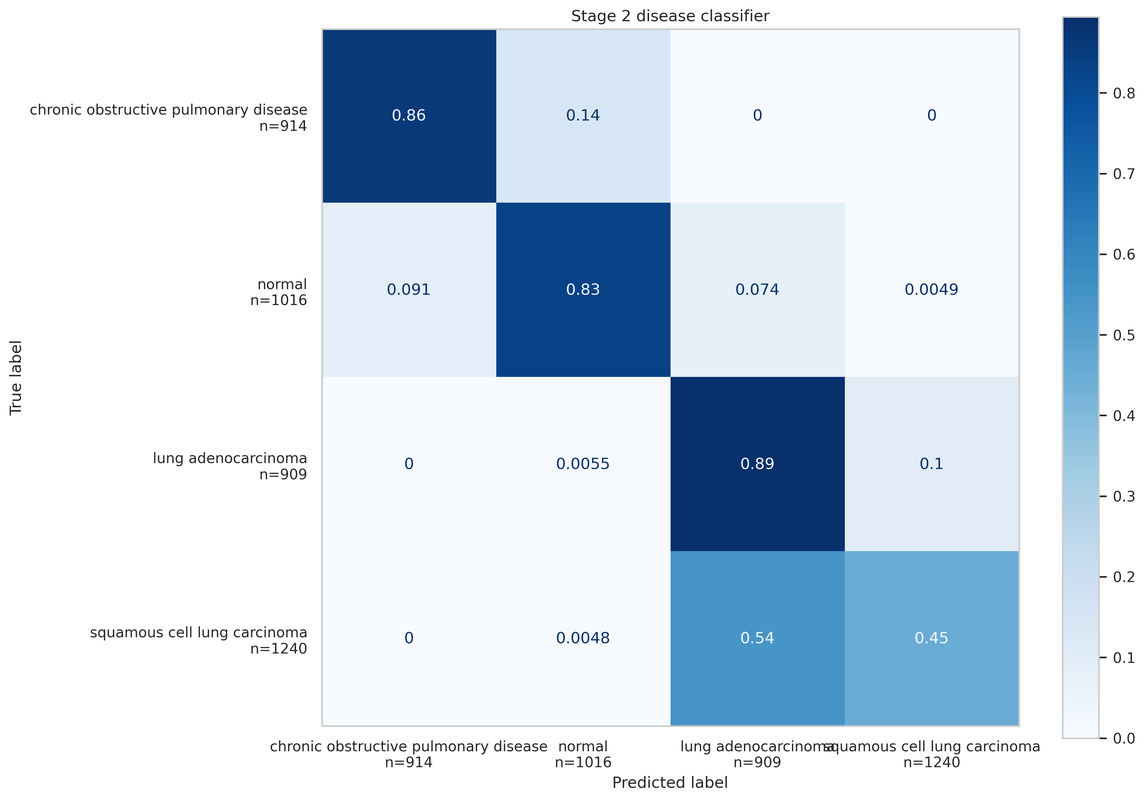

In [ ]:
#plot confusion
import matplotlib.pyplot as plt

# Screen-friendly figures for notebooks and Git review
LOW_RES_DPI = 100
plt.rcParams.update({
    "figure.dpi": LOW_RES_DPI,
    "savefig.dpi": LOW_RES_DPI,
})

# 1. Temporarily increase global chart sizes and clear text spacing
plt.rcParams.update({
    'figure.figsize': (12, 10),      # Gives the plot plenty of breathing room
    'figure.dpi': 100,               # Uses screen-friendly low resolution
    'xtick.labelsize': 9,            # Makes axis text cleanly legible
    'ytick.labelsize': 9,
    'xtick.major.pad': 5,            # Pads text away from the matrix border
    'ytick.major.pad': 5
})

# 2. Run the original unchanged function block
cc2.plot_conf_mat(
    conf_mat_dict={"Stage 2 disease classifier": test_metrics_stage2["conf_matrix"]},
    output_directory=str(STAGE2_RUN_DIR),
    output_prefix="02_disease_test",
)

# 3. Reset defaults so it doesn't distort your other script plots
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
#try plot predictions
cc2.plot_predictions(
    predictions_file=str(STAGE2_RUN_DIR / "02_disease_test_pred_dict.pkl"),
    id_class_dict_file=str(STAGE2_RUN_DIR / "02_disease_id_class_dict.pkl"),
    title="Stage 2 Geneformer V2 Disease Classifier",
    output_directory=str(STAGE2_RUN_DIR),
    output_prefix="02_disease_test",
)

In [ ]:
# next notebook compare major lung identiies accross two models

In [ ]:
import gc
import sys
import torch

# 1. List your heavy variables here to drop their tracking references
heavy_vars = ['adata_backed', 'filtered_obs', 'test_metrics', 'model', 'trainer', 'cc']

for var in heavy_vars:
    if var in globals():
        del globals()[var]
    if var in locals():
        del locals()[var]

# 2. Force Python to actively scan and collect unreferenced memory blocks
gc.collect()

# 3. Clear the PyTorch CUDA VRAM cache (Essential for GPU work)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("VRAM cache flushed successfully.")

print("Heavy workspace objects deleted and memory garbage collected.")